In [19]:
import pandas as pd
import requests

df = pd.read_csv("books.csv")
print("First 5 Rows")
print(df.head())
print("Dataset Information")
print(df.info())
print("Statistical summary")
print(df.describe())
print("Missing Values")
print(df.isnull().sum())

First 5 Rows
   bookID                                              title  \
0       1  Harry Potter and the Half-Blood Prince (Harry ...   
1       2  Harry Potter and the Order of the Phoenix (Har...   
2       4  Harry Potter and the Chamber of Secrets (Harry...   
3       5  Harry Potter and the Prisoner of Azkaban (Harr...   
4       8  Harry Potter Boxed Set  Books 1-5 (Harry Potte...   

                      authors average_rating        isbn         isbn13  \
0  J.K. Rowling/Mary GrandPré           4.57  0439785960  9780439785969   
1  J.K. Rowling/Mary GrandPré           4.49  0439358078  9780439358071   
2                J.K. Rowling           4.42  0439554896  9780439554893   
3  J.K. Rowling/Mary GrandPré           4.56  043965548X  9780439655484   
4  J.K. Rowling/Mary GrandPré           4.78  0439682584  9780439682589   

  language_code   num_pages  ratings_count  text_reviews_count  \
0           eng         652        2095690               27591   
1           eng    

In [20]:
# Step 2: Transform

# Drop rows with missing values in two columns
df = df.dropna(subset=["average_rating", "ratings_count"])

# Normalize author names (convert to uppercase, strip spaces)
df["authors"] = df["authors"].str.upper().str.strip()

# Data conversion
df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
df["ratings_count"] = pd.to_numeric(df["ratings_count"], errors="coerce")

# Derived field: Popularity Score (average rating × ratings count)
df["popularity_score"] = df["average_rating"] * df["ratings_count"]

# Check results after transformation
print(df[["title", "authors", "average_rating", "ratings_count",
          "popularity_score"]].head())


                                               title  \
0  Harry Potter and the Half-Blood Prince (Harry ...   
1  Harry Potter and the Order of the Phoenix (Har...   
2  Harry Potter and the Chamber of Secrets (Harry...   
3  Harry Potter and the Prisoner of Azkaban (Harr...   
4  Harry Potter Boxed Set  Books 1-5 (Harry Potte...   

                      authors  average_rating  ratings_count  popularity_score  
0  J.K. ROWLING/MARY GRANDPRÉ            4.57        2095690        9577303.30  
1  J.K. ROWLING/MARY GRANDPRÉ            4.49        2153167        9667719.83  
2                J.K. ROWLING            4.42           6333          27991.86  
3  J.K. ROWLING/MARY GRANDPRÉ            4.56        2339585       10668507.60  
4  J.K. ROWLING/MARY GRANDPRÉ            4.78          41428         198025.84  


In [21]:
# step - 3 Data warehouse
import sqlalchemy

# Create SQLite warehouse (books_dw.db file will be created)
engine = sqlalchemy.create_engine("sqlite:///books_dw.db")

# Dimension table: Authors
authors_dim = df[["authors"]].drop_duplicates().reset_index(drop=True)

# Fact table: Ratings + Popularity
ratings_fact = df[["title", "authors", "average_rating", "ratings_count", "popularity_score"]]

# Load into warehouse
authors_dim.to_sql("dim_authors", engine, if_exists="replace", index=False)
ratings_fact.to_sql("fact_ratings", engine, if_exists="replace", index=False)

print("Warehouse tables created: dim_authors, fact_ratings")



Warehouse tables created: dim_authors, fact_ratings


In [22]:


# Connect to the SQLite warehouse
engine = sqlalchemy.create_engine("sqlite:///books_dw.db")

# Print Authors Dimension Table
authors_dim = pd.read_sql("SELECT * FROM dim_authors", engine)
print("Authors Dimension Table:")
print(authors_dim.head())

# Print Fact Ratings Table
ratings_fact = pd.read_sql("SELECT * FROM fact_ratings", engine)
print("\nFact Ratings Table:")
print(ratings_fact.head())



Authors Dimension Table:
                      authors
0  J.K. ROWLING/MARY GRANDPRÉ
1                J.K. ROWLING
2      W. FREDERICK ZIMMERMAN
3               DOUGLAS ADAMS
4   DOUGLAS ADAMS/STEPHEN FRY

Fact Ratings Table:
                                               title  \
0  Harry Potter and the Half-Blood Prince (Harry ...   
1  Harry Potter and the Order of the Phoenix (Har...   
2  Harry Potter and the Chamber of Secrets (Harry...   
3  Harry Potter and the Prisoner of Azkaban (Harr...   
4  Harry Potter Boxed Set  Books 1-5 (Harry Potte...   

                      authors  average_rating  ratings_count  popularity_score  
0  J.K. ROWLING/MARY GRANDPRÉ            4.57        2095690        9577303.30  
1  J.K. ROWLING/MARY GRANDPRÉ            4.49        2153167        9667719.83  
2                J.K. ROWLING            4.42           6333          27991.86  
3  J.K. ROWLING/MARY GRANDPRÉ            4.56        2339585       10668507.60  
4  J.K. ROWLING/MARY GRANDPRÉ   

In [23]:
# step - 4 OLAP
# OLAP Query 1: Top 5 most popular books
top_books = pd.read_sql("""
    SELECT title, authors, popularity_score
    FROM fact_ratings
    ORDER BY popularity_score DESC
    LIMIT 5
""", engine)
print("\nTop 5 Most Popular Books:")
print(top_books)

# OLAP Query 2: Average rating per author
avg_rating_per_author = pd.read_sql("""
    SELECT authors, AVG(average_rating) AS avg_author_rating
    FROM fact_ratings
    GROUP BY authors
    ORDER BY avg_author_rating DESC
""", engine)
print("\nAverage Rating Per Author:")
print(avg_rating_per_author.head())

# OLAP Query 3: Total ratings per author
total_ratings_per_author = pd.read_sql("""
    SELECT authors, SUM(ratings_count) AS total_ratings
    FROM fact_ratings
    GROUP BY authors
    ORDER BY total_ratings DESC
""", engine)
print("\nTotal Ratings Per Author:")
print(total_ratings_per_author.head())



Top 5 Most Popular Books:
                                               title  \
0                            Twilight (Twilight  #1)   
1                The Hobbit  or There and Back Again   
2  Harry Potter and the Prisoner of Azkaban (Harr...   
3  Harry Potter and the Chamber of Secrets (Harry...   
4  Harry Potter and the Order of the Phoenix (Har...   

                      authors  popularity_score  
0             STEPHENIE MEYER       16505620.94  
1              J.R.R. TOLKIEN       10806917.38  
2  J.K. ROWLING/MARY GRANDPRÉ       10668507.60  
3  J.K. ROWLING/MARY GRANDPRÉ       10139316.46  
4  J.K. ROWLING/MARY GRANDPRÉ        9667719.83  

Average Rating Per Author:
                authors  avg_author_rating
0    WILLIAM C. DOWLING                5.0
1  TODD DAVIS/MARC FREY                5.0
2   SHERI ROSE SHEPHERD                5.0
3      SARA BARTON-WOOD                5.0
4          ROSS GARNAUT                5.0

Total Ratings Per Author:
                      a

In [28]:
# step - 5 : 
import requests
import pandas as pd

url = "https://openlibrary.org/search.json?q=python+programming"
headers = {"User-Agent": "Mozilla/5.0"}  # pretend like a browser

response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)

if response.status_code == 200:
    data = response.json()
    books = []
    for doc in data.get("docs", [])[:10]:
        books.append({
            "title": doc.get("title", "N/A"),
            "author": doc.get("author_name", ["Unknown"])[0],
            "year": doc.get("first_publish_year", "N/A")
        })
    df = pd.DataFrame(books)
    print(df)
else:
    print("API request failed with status:", response.status_code)


Status Code: 200
                             title            author  year
0          Core Python Programming  R. Nageswara Rao  2016
1                 Black Hat Python      Justin Seitz  2014
2          Core Python programming       Wesley Chun  2006
3               Python Programming     Reema Thareja  2019
4               Python programming     John M. Zelle  2003
5                  Learning Python         Mark Lutz  1999
6  Python Programming Crash Course       Alex Jaxson  2022
7               Python Programming     Sarah Stewart  2019
8               Python Programming      Adam Stewart  2016
9                           Python      Joshua Welsh  2017


In [34]:
# Step - 6: XML parsing
import xml.etree.ElementTree as ET
import pandas as pd

tree = ET.parse("books.xml")   # make sure books.xml is in same folder
root = tree.getroot()

xml_books = []
for book in root.findall("book"):
    xml_books.append({
        "title": book.find("title").text,
        "author": book.find("author").text,
        "price": float(book.find("price").text)
    })

xml_df = pd.DataFrame(xml_books)
print(xml_df)


                   title              author  price
0               Let Us C  Yashavant Kanetkar  350.0
1              Core Java     Herbert Schildt  500.0
2    Python Crash Course        Eric Matthes  450.0
3  Programming in ANSI C     E. Balagurusamy  400.0


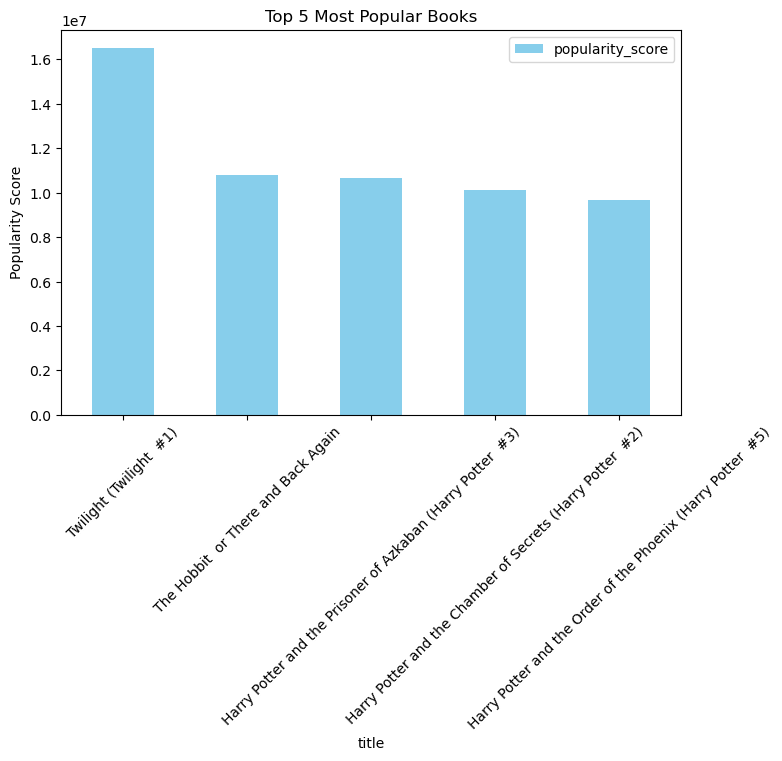

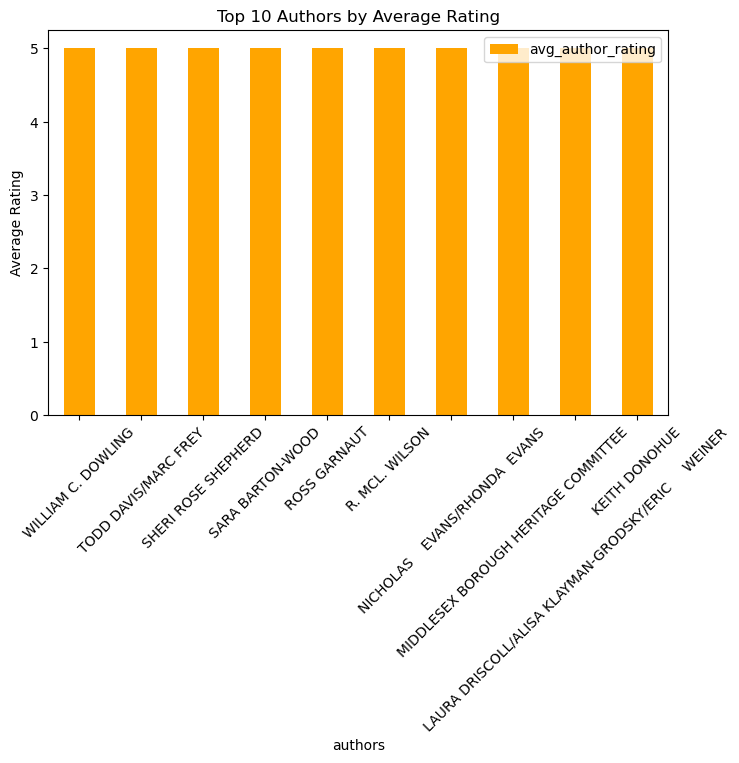

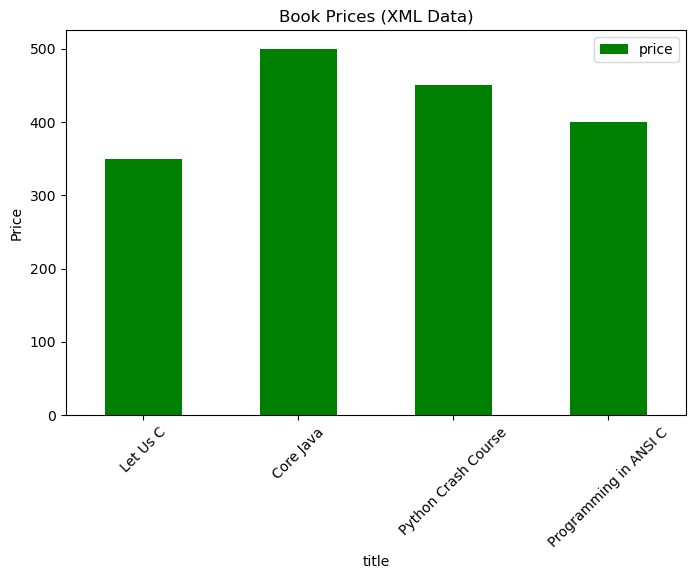

In [36]:
import matplotlib.pyplot as plt

# Visualization 1: Top 5 most popular books (titles on x-axis)
top_books.plot(x="title", y="popularity_score", kind="bar", figsize=(8,5), color="skyblue")
plt.title("Top 5 Most Popular Books")
plt.ylabel("Popularity Score")
plt.xticks(rotation=45)
plt.show()

# Visualization 2: Average rating per author (authors on x-axis)
avg_rating_per_author.head(10).plot(x="authors", y="avg_author_rating", kind="bar", figsize=(8,5), color="orange")
plt.title("Top 10 Authors by Average Rating")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

# Visualization 3: Price distribution of XML books (titles on x-axis)
xml_df.plot(x="title", y="price", kind="bar", figsize=(8,5), color="green")
plt.title("Book Prices (XML Data)")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()
